Crazy loss bro

In [90]:
import torch 
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [91]:
live = pd.read_csv("../data/samples/mega_processed/live_avg.csv")
verbose = pd.read_csv("../data/samples/mega/verbose_statements.csv")
initial = pd.read_csv("../data/samples/mega/initial_statement.csv")

In [92]:
live = live.drop(columns=['Unnamed: 0'])

In [93]:
# response_time = verbose['total_duration'].tolist()
# response_time = response_time[:-1]
# reset_iters = live[live['Iteration'] == 1].index.tolist()

# gpu_util_avg = []
# memory_util_avg = []
# clock_util_avg = []

# for i in range(1, len(reset_iters)):
#     temp_metrics = live.dropna()
#     gpu_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], 3].tolist()
#     memeory_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], 9].tolist()
#     clock_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], -2].tolist()
#     gpu_util_avg.append(np.average(gpu_util_prompt))
#     memory_util_avg.append(np.average(memeory_util_prompt))
#     clock_util_avg.append(np.average(clock_util_prompt))

In [94]:
gpu_util_avg = live['GPU Utilization (%)']
memory_util_avg = live['Memory Utilization (%)']
clock_util_avg = live['GPU Clock Utilization']
response_time = live['Resonse Time']

In [95]:
data = []

for (x, y, z, i) in zip(gpu_util_avg, memory_util_avg, clock_util_avg, response_time[:-1]):
    data.append([torch.Tensor([x, y, z]), torch.Tensor([i])])

In [96]:
class BenchMark(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.l1 = nn.Sequential(
            nn.Linear(input_features, 32),
            nn.ReLU()
        )
        self.l2 = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.l3 = nn.Linear(16, output_features)

    def forward(self, x):
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        return x

In [97]:
model = BenchMark(3, 3)

In [99]:
train_data = data[:370]
test_data = data[370:400]

train_dataloader = DataLoader(train_data, batch_size=10, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=10, shuffle=True)

In [100]:
device = 'cuda' if torch.cuda.is_available() else "cpu"

In [106]:
def minimize_avg_time_loss(predicted, nums, ans):
    total_sum = 0
    # print(f"Predicted tensor-> Before: {predicted} & After: {predicted[0].item()}")
    for i in range(3):
        total_sum += (predicted[i].item()*nums[i].item()) 
        # total_sum = np.array(total_sum)
        pass
    total_sum = torch.tensor([total_sum], requires_grad=True)
    # print(f"Answer tensor-> {ans} & Total Sum Tesnor-> {total_sum}")
    loss = nn.MSELoss()
    net_loss = loss(total_sum, ans) 
    return net_loss

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [ ]:
model.to(device)
model.train()
total_loss = []
for batch, (X, y) in enumerate(train_dataloader):
    for X_mini, y_mini in zip(X, y):
        # X_mini.to(device), y.to(device)
        preds = model(X_mini.to(device))
        loss = minimize_avg_time_loss(preds, X_mini, y_mini)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss.append(loss.detach().numpy())
        print("Current Loss: ")
        print(loss.detach())

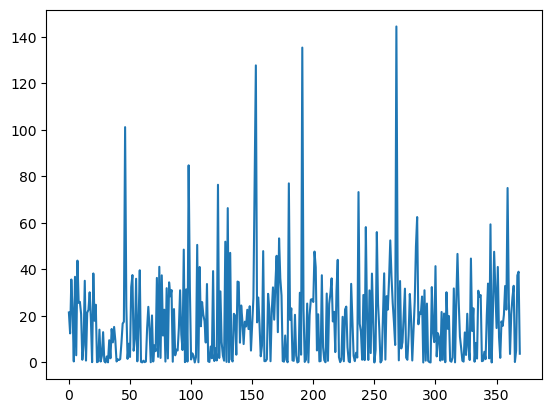

In [108]:
y = pd.Series(total_loss)
x = range(len(response_time[:370]))
plt.plot(x, y)
plt.show()